Shape: (70000, 18)
First rows:
    Chest Pain  Shortness of Breath  Irregular Heartbeat  Fatigue & Weakness  \
0           0                    1                    1                   1   
1           0                    0                    1                   0   
2           1                    0                    0                   1   

   Dizziness  Swelling (Edema)  Pain in Neck/Jaw/Shoulder/Back  \
0          0                 0                               0   
1          0                 1                               0   
2          1                 1                               0   

   Excessive Sweating  Persistent Cough  Nausea/Vomiting  High Blood Pressure  \
0                   1                 1                1                    0   
1                   0                 0                0                    1   
2                   0                 1                0                    0   

   Chest Discomfort (Activity)  Cold Hands/Feet  Snoring/Slee

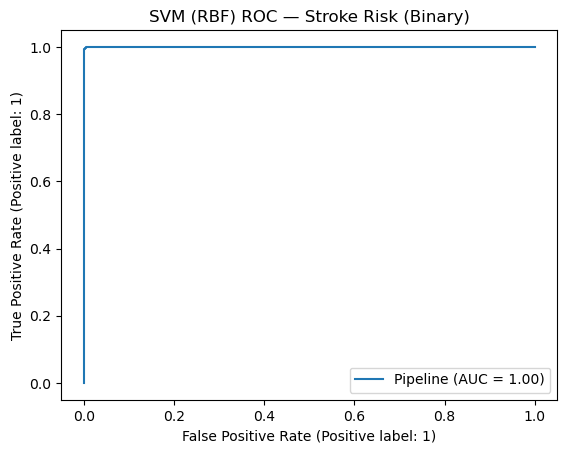


Top features by absolute linear weight:
 Age                          21.051679
Fatigue_Weakness              4.999028
Persistent_Cough              4.999023
Snoring_Sleep_Apnea           4.999021
Chest_Discomfort_Activity     4.999013
Irregular_Heartbeat           4.999007
Anxiety_Feeling_of_Doom       4.999003
Swelling_Edema                4.998995
Cold_Hands_Feet               4.998987
Chest_Pain                    4.998983
dtype: float64
Intercept b = 11.124678


In [1]:
# ============================
# Stroke Risk (Binary) — SVM Lab
# ============================

import re
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, RocCurveDisplay
)
import matplotlib.pyplot as plt

# 1) Load CSV ---------------------------------------------------------------
# Put the CSV in the same folder or adjust the path accordingly.
CSV_PATH = Path("/Users/rongrongqian/Desktop/AI modules/svm/stroke_risk_dataset.csv") #change the path
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("First rows:\n", df.head(3))

# 2) Clean column names (safer for pandas / scikit-learn)
# Replace spaces and special chars with underscores: "At Risk (Binary)" -> "At_Risk_Binary"
df.columns = [re.sub(r"[^0-9A-Za-z]+", "_", c).strip("_") for c in df.columns]
print("\nRenamed columns:\n", df.columns.tolist())

# 3) Define target and drop any leakage columns -----------------------------
# Target is the binary label (0/1). Avoid using the risk percentage as a feature.
TARGET = "At_Risk_Binary"
LEAK_COLS = ["Stroke_Risk", "Stroke_Risk_", "Stroke_Risk__"]  # handles "Stroke Risk (%)" variations

# Keep only leakage columns that actually exist, then drop
leaks_present = [c for c in LEAK_COLS if c in df.columns]
X = df.drop(columns=[c for c in leaks_present + [TARGET] if c in df.columns]).copy()
y = df[TARGET].astype(int)

# 4) Basic preprocessing ----------------------------------------------------
# Fill numeric missing values with medians (this dataset should be mostly 0/1 + Age)
for c in X.columns:
    if pd.api.types.is_numeric_dtype(X[c]):
        X[c] = X[c].fillna(X[c].median())
    else:
        # If any categorical strings appear, one-hot encode them
        X = pd.get_dummies(X, columns=[c], drop_first=True)

# 5) Train / test split--------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 6) Pipeline: Standardize + SVM Radial Basis Function (RBF) ---------------
# class_weight="balanced" helps when classes are imbalanced.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

# 7) Simple hyperparameter search ------------------------------------------
param_grid = {
    "svm__C": [0.5, 1, 5, 10],
    "svm__gamma": ["scale", 0.1, 0.01, 0.001]
}
grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1, scoring="f1")
grid.fit(X_train, y_train)

best = grid.best_estimator_
print("\nBest params:", grid.best_params_)

# 8) Evaluation -------------------------------------------------------------
y_pred = best.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred, digits=3))

# 9) ROC curve (SVC has decision_function; good enough for ROC) -------------
RocCurveDisplay.from_estimator(best, X_test, y_test)
plt.title("SVM (RBF) ROC — Stroke Risk (Binary)")
plt.show()

# 10) (Optional) Linear SVM for feature weights ----------------------------
# If you want interpretable weights, train a linear-kernel SVM on the same split.
lin_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", class_weight="balanced"))
])
lin_clf.fit(X_train, y_train)

# Coefficients are available only for linear kernel; shape is (1, n_features)
coefs = lin_clf.named_steps["svm"].coef_.ravel()
feat_importance = pd.Series(coefs, index=X.columns).sort_values(key=np.abs, ascending=False)
print("\nTop features by absolute linear weight:\n", feat_importance.head(10))

b = float(lin_clf.named_steps["svm"].intercept_)
print(f"Intercept b = {b:.6f}")

